Ajuste de parámetros de data industrial

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import savgol_filter
from scipy.interpolate import UnivariateSpline
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares
from scipy.optimize import differential_evolution

In [4]:
path_excel = r"C:\Users\MARIA\OneDrive - Universidad Católica de Chile\Escritorio\Concha y Toro\Datos históricos\CS\100.000 L\Data CS 25 LOU estanque 56.xlsx"
# path_excel = r"C:\Users\MARIA\OneDrive - Universidad Católica de Chile\Escritorio\Concha y Toro\Códigos\Data CS 25 LOU estanque 45.xlsx"
# path_excel = r"C:\Users\MARIA\OneDrive - Universidad Católica de Chile\Escritorio\Concha y Toro\Datos históricos\2024\MA 24 LOU\Data MA 24 LOU estanque 213.xlsx"

df = pd.read_excel(path_excel, header=None)
# header = None, para que no tome la primera fila como encabezado y se lea tal cual como está en el archivo Excel

In [5]:
xls_estudiado = pd.ExcelFile(path_excel)
# xls_estudiado.sheet_names

In [6]:
# === Convertir el valor a número (manejo de coma decimal) ===
def to_float(x):
    if isinstance(x, str):
        x = x.replace(",", ".")
    try:
        return float(x)
    except:
        return np.nan

### Datos de hoja "Antecedentes"

In [7]:
df_antecedentes = pd.read_excel(
    path_excel,
    sheet_name="Antecedentes")

In [8]:
# === Obtener la columna "ant_vino_estimado_l" ===
col_vino = df_antecedentes.columns.get_loc("ant_vino_estimado_l")

# === Obtener el valor de esa columna ===
vol_Tot_raw = df_antecedentes.iloc[0, col_vino]
print(f'"ant_vino_estimado_l" encontrado en columna {col_vino}')
print("\nValor crudo extraído:", vol_Tot_raw)
vol_Tot = to_float(vol_Tot_raw)

# === Resultado final ===
print("\nVol_Tot extraído correctamente =", vol_Tot)

"ant_vino_estimado_l" encontrado en columna 35

Valor crudo extraído: 63442.5

Vol_Tot extraído correctamente = 63442.5


In [9]:
# === Obtener la columna "oper_inicio_brix" ===
col_brix_inicial = df_antecedentes.columns.get_loc("oper_inicio_brix")

# === Obtener el valor de esa columna ===
brix_inicial_raw = df_antecedentes.iloc[0, col_brix_inicial]
print(f'"oper_inicio_brix" encontrado en columna {col_brix_inicial}')
print("\nValor crudo extraído:", brix_inicial_raw)
brix_inicial = to_float(brix_inicial_raw)

# === Resultado final ===
print("\nBrix_inicial extraído correctamente =", brix_inicial)

"oper_inicio_brix" encontrado en columna 82

Valor crudo extraído: 23.29998868

Brix_inicial extraído correctamente = 23.29998868


### Datos de hoja "Laboratorio"

In [10]:
df_lab = pd.read_excel(
    path_excel,
    sheet_name="Laboratorio")

In [11]:
# === Buscar la palabra "YAN" en cualquier celda ===
mask_YAN = df_lab.astype(str).apply(
    lambda col: col.str.contains("YAN", case=False, na=False)
)

# === Obtener la posición (fila, columna) donde aparece "YAN" ===
rows_YAN, cols_YAN = np.where(mask_YAN.values)

# Tomamos la primera coincidencia e imprimimos su posición
# print(f'"YAN" encontrado en fila {rows_YAN[0]}, columna {cols_YAN[0]}')

# === Tomar el valor que está en 4 columnas hacia la derecha de "YAN" ===
yan_raw = df_lab.iloc[rows_YAN[0], cols_YAN[0] + 4]
# print("\nValor crudo extraído:", yan_raw)

YAN_0 = to_float(yan_raw)

# === Resultado final ===
print(f"YAN extraído correctamente = {YAN_0} mg/L")

YAN extraído correctamente = 155.0 mg/L


In [12]:
# === Buscar la palabra "Alcohol" en cualquier celda ===
mask_Alcohol = df_lab.astype(str).apply(
    lambda col: col.str.contains("Alcohol", case=False, na=False)
)

# === Obtener la posición (fila, columna) donde aparece "Alcohol" ===
rows_Alcohol, cols_Alcohol = np.where(mask_Alcohol.values)

# Tomamos la primera coincidencia e imprimimos su posición
# print(f'"Alcohol" encontrado en fila {rows_Alcohol[0]}, columna {cols_Alcohol[0]}')

# === Tomar el valor que está en 4 columnas hacia la derecha de "Alcohol" ===
alcohol_raw = df_lab.iloc[rows_Alcohol[0], cols_Alcohol[0] + 4]
# print("\nValor crudo extraído:", alcohol_raw)

grado_alcohol = to_float(alcohol_raw)

# === Resultado final ===
print(f"Alcohol extraído correctamente = {grado_alcohol}°")

# === Convertir grado alcohólico a L de alcohol en el volumen total ===
# 789,3 g/L es la densidad del alcohol etílico a 20 °C
alcohol_final_obs = grado_alcohol / 100 * 789.3 
print(f"Litros de alcohol en el volumen total = {alcohol_final_obs:.3f} g/L")

Alcohol extraído correctamente = 11.7°
Litros de alcohol en el volumen total = 92.348 g/L


### Datos de hoja "Insumos Operacionales"

In [13]:
df_insumos = pd.read_excel(
    path_excel,
    sheet_name="Insumos Operacionales")

In [14]:
# === Buscar la palabra "Sangría" en cualquier celda ===
mask_vol_sang = df_insumos.astype(str).apply(
    lambda col: col.str.contains("Sangría", case=False, na=False)
)

# === Obtener la posición (fila, columna) donde aparece "Sangría" ===
rows_vol_sang, cols_vol_sang = np.where(mask_vol_sang.values)

# Tomamos la primera coincidencia e imprimimos su posición
print(f'"Sangría" encontrado en fila {rows_vol_sang[0]}, columna {cols_vol_sang[0]}')

# === Tomar el valor que está 1 columna hacia la derecha de "Sangría" ===
if df_insumos.iloc[rows_vol_sang[0], cols_vol_sang[0] + 1] > 0:
    vol_sang_raw = df_insumos.iloc[rows_vol_sang[0], cols_vol_sang[0] + 1]
else: # Si es Nan es 0
    vol_sang_raw = 0

print("\nValor crudo extraído:", vol_sang_raw)

vol_sang = to_float(vol_sang_raw)

# === Resultado final ===
print("\nVolumen Sangría extraído correctamente =", vol_sang)

"Sangría" encontrado en fila 8, columna 3

Valor crudo extraído: 4000.0

Volumen Sangría extraído correctamente = 4000.0


In [15]:
# === Buscar la palabra "Free K" en cualquier celda ===
mask_vol_freek = df_insumos.astype(str).apply(
    lambda col: col.str.contains("Free K", case=False, na=False)
)

# === Obtener la posición (fila, columna) donde aparece "Free K" ===
rows_vol_freek, cols_vol_freek = np.where(mask_vol_freek.values)

# Tomamos la primera coincidencia e imprimimos su posición
print(f'"Free K" encontrado en fila {rows_vol_freek[0]}, columna {cols_vol_freek[0]}')

# === Tomar el valor que está 1 columna hacia la derecha de "Free K"  si tiene número ===
if df_insumos.iloc[rows_vol_freek[0], cols_vol_freek[0] + 1] > 0:
    vol_freek_raw = df_insumos.iloc[rows_vol_freek[0], cols_vol_freek[0] + 1]
else: # Si es Nan es 0 
    vol_freek_raw = 0

print("\nValor crudo extraído:", vol_freek_raw)

vol_freek = to_float(vol_freek_raw)

# === Resultado final ===
print("\nVolumen Free K extraído correctamente =", vol_freek)

"Free K" encontrado en fila 4, columna 3

Valor crudo extraído: 5000.0

Volumen Free K extraído correctamente = 5000.0


In [16]:
# === Buscar la palabra "Ácido tartárico" en cualquier celda ===
mask_vol_tart = df_insumos.astype(str).apply(
    lambda col: col.str.contains("Ácido tartárico", case=False, na=False)
)

# === Obtener la posición (fila, columna) donde aparece "Ácido tartárico" ===
rows_vol_tart, cols_vol_tart = np.where(mask_vol_tart.values)

# Tomamos la primera coincidencia e imprimimos su posición
print(f'"Ácido tartárico" encontrado en fila {rows_vol_tart[0]}, columna {cols_vol_tart[0]}')

# === Tomar el valor que está 1 columna hacia la derecha de "Ácido tartárico" ===
if df_insumos.iloc[rows_vol_tart[0], cols_vol_tart[0] + 2] == "(L)":
    vol_tart_raw = df_insumos.iloc[rows_vol_tart[0], cols_vol_tart[0] + 1]
else:
    vol_tart_raw = 0

print("\nValor crudo extraído:", vol_tart_raw)

vol_tart = to_float(vol_tart_raw)

# === Resultado final ===
print("\nVolumen Ácido tartárico extraído correctamente =", vol_tart)

"Ácido tartárico" encontrado en fila 1, columna 3

Valor crudo extraído: 0

Volumen Ácido tartárico extraído correctamente = 0.0


In [17]:
# === Buscar la palabra "Agua vegetal" en cualquier celda ===
mask_vol_agua = df_insumos.astype(str).apply(
    lambda col: col.str.contains("Agua vegetal", case=False, na=False)
)

# === Obtener la posición (fila, columna) donde aparece "Agua vegetal" ===
rows_vol_agua, cols_vol_agua = np.where(mask_vol_agua.values)

# Tomamos la primera coincidencia e imprimimos su posición
print(f'"Agua vegetal" encontrado en fila {rows_vol_agua[0]}, columna {cols_vol_agua[0]}')

# === Tomar el valor que está 1 columna hacia la derecha de "Agua vegetal"  si tiene número ===
if df_insumos.iloc[rows_vol_agua[0], cols_vol_agua[0] + 1] > 0:
    vol_agua_raw = df_insumos.iloc[rows_vol_agua[0], cols_vol_agua[0] + 1]
else: # Si es Nan es 0 
    vol_agua_raw = 0

print("\nValor crudo extraído:", vol_agua_raw)

vol_agua = to_float(vol_agua_raw)

# === Resultado final ===
print("\nVolumen Agua vegetal extraído correctamente =", vol_agua)

"Agua vegetal" encontrado en fila 2, columna 3

Valor crudo extraído: 0

Volumen Agua vegetal extraído correctamente = 0.0


In [18]:
# === Buscar la palabra "Mosto concentrado" en cualquier celda ===
mask_vol_conc = df_insumos.astype(str).apply(
    lambda col: col.str.contains("Mosto concentrado", case=False, na=False)
)

# === Obtener la posición (fila, columna) donde aparece "Mosto concentrado" ===
rows_vol_conc, cols_vol_conc = np.where(mask_vol_conc.values)

# Tomamos la primera coincidencia e imprimimos su posición
print(f'"Mosto concentrado" encontrado en fila {rows_vol_conc[0]}, columna {cols_vol_conc[0]}')

# === Tomar el valor que está 1 columna hacia la derecha de "Mosto concentrado"  si tiene número ===
if df_insumos.iloc[rows_vol_conc[0], cols_vol_conc[0] + 1] > 0:
    vol_conc_raw = df_insumos.iloc[rows_vol_conc[0], cols_vol_conc[0] + 1]
else: # Si es Nan es 0 
    vol_conc_raw = 0

print("\nValor crudo extraído:", vol_conc_raw)

vol_conc = to_float(vol_conc_raw)

# === Resultado final ===
print("\nVolumen Mosto concentrado extraído correctamente =", vol_conc)

"Mosto concentrado" encontrado en fila 6, columna 3

Valor crudo extraído: 0

Volumen Mosto concentrado extraído correctamente = 0.0


In [19]:
# === Buscar la palabra "FDA" (puede venir en L o en kg) ===
mask_vol_FDA = df_insumos.astype(str).apply(
    lambda col: col.str.contains("FDA", case=False, na=False)
)

rows_vol_FDA, cols_vol_FDA = np.where(mask_vol_FDA.values)

fda_entries = []
for r, c in zip(rows_vol_FDA, cols_vol_FDA):
    if c + 2 >= df_insumos.shape[1]:
        continue
    unidad = str(df_insumos.iloc[r, c + 2]).strip()
    es_volumen = unidad in ["(L)", "L"]
    es_kg = unidad in ["(kg)", "kg"]
    if not (es_volumen or es_kg):
        continue
    vol_raw = df_insumos.iloc[r, c + 1] if es_volumen else 0
    dosis_raw = df_insumos.iloc[r, c + 4] if c + 4 < df_insumos.shape[1] else 0
    fecha_raw = df_insumos.iloc[r, c + 7] if c + 7 < df_insumos.shape[1] else None
    densidad_raw = df_insumos.iloc[r, c + 8] if c + 8 < df_insumos.shape[1] else np.nan
    densidad_ok = False
    densidad_val = to_float(densidad_raw)
    if not pd.isna(densidad_val) and densidad_val >= 1000:
        densidad_ok = True
    fda_entries.append(
        {
            "row": r,
            "col": c,
            "volumen_raw": vol_raw,
            "dosis_raw": dosis_raw,
            "fecha_raw": fecha_raw,
            "densidad_raw": densidad_raw,
            "densidad_ok": densidad_ok,
        }
    )

# Ordenar y separar en dosis principal y tardia (si hay densidad medida)
fda_entries = sorted(fda_entries, key=lambda e: e["row"])
principal = fda_entries[0] if fda_entries else None
adicional = next((e for e in fda_entries[1:] if e["densidad_ok"]), None)

vol_FDA = to_float(principal["volumen_raw"]) if principal else 0
dosis_FDA = to_float(principal["dosis_raw"]) if principal else 0
fecha_FDA = pd.to_datetime(principal["fecha_raw"], errors="coerce", dayfirst=True) if principal else pd.NaT

vol_FDA_extra = to_float(adicional["volumen_raw"]) if adicional else 0
dosis_FDA_extra = to_float(adicional["dosis_raw"]) if adicional else 0
fecha_FDA_extra = pd.to_datetime(adicional["fecha_raw"], errors="coerce", dayfirst=True) if adicional else pd.NaT

# Validar densidad de la FDA adicional
densidad_extra_val = to_float(adicional["densidad_raw"]) if adicional else np.nan
if adicional is None or pd.isna(densidad_extra_val) or densidad_extra_val < 1000:
    vol_FDA_extra = 0
    dosis_FDA_extra = 0
    fecha_FDA_extra = pd.NaT

# Conversion de YAN de la dosis tardia
yan_FDA_extra = dosis_FDA_extra * 25 / 10

# Horas entre dosis inicial y tardia
horas_post_FDA = 0
if not (pd.isna(fecha_FDA) or pd.isna(fecha_FDA_extra)):
    delta = fecha_FDA_extra - fecha_FDA
    horas_post_FDA = max(delta.total_seconds() / 3600, 0)
    
# dosis_FDA = dosis_FDA / 10 #ERROR EN PLANILLA EXCEL

print(f'FDA principal: volumen={vol_FDA}, dosis={dosis_FDA}')
print(f'FDA adicional: volumen={vol_FDA_extra}, dosis={dosis_FDA_extra}, YAN_extra={yan_FDA_extra}, horas_post={horas_post_FDA}')



FDA principal: volumen=0.0, dosis=0.0
FDA adicional: volumen=0, dosis=0, YAN_extra=0.0, horas_post=0


In [20]:
# === Buscar la palabra "Levadura" en cualquier celda ===
mask_vol_levadura = df_insumos.astype(str).apply(
    lambda col: col.str.contains("Levadura", case=False, na=False)
)

# === Obtener la posición (fila, columna) donde aparece "Levadura" ===
rows_vol_levadura, cols_vol_levadura = np.where(mask_vol_levadura.values)

# Tomamos la primera coincidencia e imprimimos su posición
print(f'"Levadura" encontrado en fila {rows_vol_levadura[0]}, columna {cols_vol_levadura[0]}')

# === Tomar el valor que está 1 columna hacia la derecha de "Levadura"  si tiene número ===
if df_insumos.iloc[rows_vol_levadura[0], cols_vol_levadura[0] + 1] > 0:
    vol_levadura_raw = df_insumos.iloc[rows_vol_levadura[0], cols_vol_levadura[0] + 1]
    if df_insumos.iloc[rows_vol_levadura[0], cols_vol_levadura[0] + 10] > 0:
        if df_insumos.iloc[rows_vol_levadura[0], cols_vol_levadura[0] + 10] < 1e6 :
            poblacion_levadura_raw = df_insumos.iloc[rows_vol_levadura[0], cols_vol_levadura[0] + 10] * 1e6
        else:
            poblacion_levadura_raw = df_insumos.iloc[rows_vol_levadura[0], cols_vol_levadura[0] + 10]
    else:
        poblacion_levadura_raw = 0
else: # Si es Nan es 0 
    vol_levadura_raw = 0
    poblacion_levadura_raw = 0

print("\nValor crudo extraído:", vol_levadura_raw, poblacion_levadura_raw)

vol_levadura = to_float(vol_levadura_raw)
poblacion_levadura = to_float(poblacion_levadura_raw)

# === Resultado final ===
print("\nVolumen Levadura extraído correctamente =", vol_levadura)
print("\nPoblación Levadura extraído correctamente =", poblacion_levadura)

"Levadura" encontrado en fila 5, columna 3

Valor crudo extraído: 350.0 520000000.0

Volumen Levadura extraído correctamente = 350.0

Población Levadura extraído correctamente = 520000000.0


### Cálculos

In [21]:
def volumen_total(vol_mosto, vol_sang, vol_tart, vol_freek, vol_agua, vol_conc, vol_fda):
    vol_post_sangria = vol_mosto - vol_sang
    vol_final = vol_post_sangria + vol_tart + vol_freek + vol_agua + vol_conc + vol_fda
    vol_plataforma = vol_post_sangria + vol_tart + vol_freek
    return vol_post_sangria, vol_final, vol_plataforma

In [22]:
volumen = volumen_total(vol_Tot, vol_sang, vol_tart, vol_freek, vol_agua, vol_conc, vol_FDA)
vol_post_sangria = volumen[0]
vol_tot = volumen[1]
vol_plataforma = volumen[2]

In [23]:
def calculo_conc_YAN_inicial(volumen, vol_post_sangria, YAN_0, dosis_FDA):
    FDA_agregado = dosis_FDA * 25/10 # mg/L
    # print(FDA_agregado)
    ajuste_YAN_vol = vol_post_sangria * YAN_0
    # print((ajuste_YAN_vol + FDA_agregado * volumen) / volumen)
    return (ajuste_YAN_vol + FDA_agregado * volumen) / volumen

In [24]:
Conc_YAN_ini = calculo_conc_YAN_inicial(vol_tot, vol_post_sangria, YAN_0, dosis_FDA)

print(f'Concentración inicial de YAN: {Conc_YAN_ini:.2f} (mg/L)')

Concentración inicial de YAN: 142.97 (mg/L)


In [25]:
print(f'YAN adicional por FDA tardia: {yan_FDA_extra:.2f} mg/L')
print(f'Horas despues de la FDA inicial: {horas_post_FDA:.2f} h')

YAN adicional por FDA tardia: 0.00 mg/L
Horas despues de la FDA inicial: 0.00 h


In [26]:
def calculo_conc_biomasa_inicial(volumen, vol_levadura, poblacion_levadura):
    # 2.8571e-11 g -> 1 célula de levadura
    if poblacion_levadura != 0:
        concentracion_biomasa = (poblacion_levadura * 2.8571e-11 * 1000)  # g/L
        masa_biomasa = concentracion_biomasa * vol_levadura
        return concentracion_biomasa, masa_biomasa / volumen
    else: 
        return 0.0, 0.0595

In [27]:
Biomasa = calculo_conc_biomasa_inicial(vol_tot, vol_levadura, poblacion_levadura)

print(f'Concentración inicial de biomasa: {Biomasa[0]:.3f} (g/L)')
print(f'Concentración inicial en reactor: {Biomasa[1]:.5f} (g/L)')

Concentración inicial de biomasa: 14.857 (g/L)
Concentración inicial en reactor: 0.08069 (g/L)


### Suavizado y perfiles horarios (densidad -> azúcares y temperaturas)

In [28]:
# === Funciones auxiliares para suavizado ===
def densidad_to_sugar(densidad):
    """Convierte densidad (g/L) a concentración de azúcar (g/L)."""
    return 2.5616 * densidad - 2577.4

def brix_to_sugar(brix):
    """Convierte grados Brix a concentración de azúcar (g/L)."""
    return 12 * brix - 40

def estimate_noise_residual(y, window, poly):
    """Ruido efectivo via Savitzky-Golay fuerte + sigma de residuos."""
    y = pd.to_numeric(y, errors="coerce").to_numpy(dtype=float)
    mask = ~np.isnan(y)
    yv = y[mask]
    if len(yv) < window:
        return np.nan
    y_smooth = savgol_filter(yv, window_length=window, polyorder=poly)
    return np.std(yv - y_smooth, ddof=1)

noise_cfg = {"temp": {"window": 81, "poly": 1}, "dens": {"window": 51, "poly": 1}}
spline_cfg = {"alpha_temp": 1.0, "alpha_dens": 1.0}


In [29]:
# === Cargar hoja de sensores y limpiar ===
sheet_sensores = "Prov Sensores"
col_time = "indice_tiempo_dias"
col_dens = "densidad"
col_tm = "temp_mosto"
col_ts = "temp_sombrero"
col_sp = "temp_setpoint"

df_sens = pd.read_excel(path_excel, sheet_name=sheet_sensores)
df_sens = df_sens[[col_time, col_dens, col_tm, col_ts, col_sp]].copy()
for c in df_sens.columns:
    df_sens[c] = pd.to_numeric(df_sens[c], errors="coerce")

df_sens = df_sens.dropna(subset=[col_time]).sort_values(col_time).reset_index(drop=True)
df_sens["temp_promedio_raw"] = df_sens[[col_tm, col_ts]].mean(axis=1)

t_hours = (df_sens[col_time].to_numpy()) * 24

print(f"Puntos con tiempo: {len(t_hours)} | densidad válidas: {df_sens[col_dens].notna().sum()}")


Puntos con tiempo: 1996 | densidad válidas: 1435


In [30]:
# === Estimar ruido y ajustar splines ===
sigma_temp = estimate_noise_residual(df_sens[col_tm], noise_cfg["temp"]["window"], noise_cfg["temp"]["poly"])
sigma_dens = estimate_noise_residual(df_sens[col_dens], noise_cfg["dens"]["window"], noise_cfg["dens"]["poly"])

N_temp = df_sens[col_tm].notna().sum()
N_dens = df_sens[col_dens].notna().sum()

s_temp = max(spline_cfg["alpha_temp"] * N_temp * (0 if np.isnan(sigma_temp) else sigma_temp**2), 0)
s_dens = max(spline_cfg["alpha_dens"] * N_dens * (0 if np.isnan(sigma_dens) else sigma_dens**2), 0)

def fit_spline(y, s):
    mask = ~np.isnan(y)
    return UnivariateSpline(t_hours[mask], y[mask], s=s, k=2)

spline_dens = fit_spline(df_sens[col_dens].to_numpy(), s_dens)
spline_tm   = fit_spline(df_sens[col_tm].to_numpy(), s_temp)
spline_ts   = fit_spline(df_sens[col_ts].to_numpy(), s_temp)
spline_tp   = fit_spline(df_sens["temp_promedio_raw"].to_numpy(), s_temp)

dens_spline_full = spline_dens(t_hours)
tm_spline_full   = spline_tm(t_hours)
ts_spline_full   = spline_ts(t_hours)
tp_spline_full   = spline_tp(t_hours)

azucar_raw = densidad_to_sugar(df_sens[col_dens])
azucar_spline_full = densidad_to_sugar(dens_spline_full)

print(f"sigma_temp~{sigma_temp:.3f} | sigma_dens~{sigma_dens:.3f} | s_temp={s_temp:.1f} | s_dens={s_dens:.1f}")


sigma_temp~0.366 | sigma_dens~1.465 | s_temp=266.5 | s_dens=3078.4


In [32]:
# === Punto de inicio optimizado y muestreo ===
idx_first_density = df_sens.index[df_sens[col_dens].notna()].tolist()
if not idx_first_density:
    raise ValueError("No hay mediciones de densidad en la hoja 'Prov Sensores'.")
first_density_hour = t_hours[idx_first_density[0]]

sp_vals = pd.to_numeric(df_sens[col_sp], errors="coerce").to_numpy()
idx_sp_range = np.where((sp_vals >= 27) & (sp_vals <= 29))[0]
idx_sp_up = None
for idx in idx_sp_range:
    prev = sp_vals[idx - 1] if idx > 0 else np.nan
    if np.isnan(prev) or prev < 27:
        idx_sp_up = idx
        break
if idx_sp_up is None and len(idx_sp_range) > 0:
    idx_sp_up = idx_sp_range[0]

sp_start_hour = t_hours[idx_sp_up] if idx_sp_up is not None else first_density_hour
t_start_opt = max(first_density_hour, sp_start_hour)

t_muestreo = 8
t_opt = np.arange(t_start_opt, t_hours.max() + 1e-6, t_muestreo) # último número cada cuantas horas
if t_opt[-1] < t_hours.max():
    t_opt = np.append(t_opt, t_hours.max())

dens_opt = spline_dens(t_opt)
tm_opt   = spline_tm(t_opt)
ts_opt   = spline_ts(t_opt)
tp_opt   = spline_tp(t_opt)
azucar_opt = densidad_to_sugar(dens_opt)

sp_clean = pd.Series(sp_vals).interpolate(limit_direction="both").to_numpy()
setpoint_opt = np.interp(t_opt, t_hours, sp_clean)

perfiles_optimizados = {
    "t_horas": t_opt,
    "densidad": dens_opt,
    "azucar": azucar_opt,
    "temp_mosto": tm_opt,
    "temp_sombrero": ts_opt,
    "temp_promedio": tp_opt,
    "setpoint": setpoint_opt,
    "t_inicio_opt_h": t_start_opt,
}

print(f"Inicio optimizado: {t_start_opt:.1f} h")
print(f"Puntos horarios optimizados: {len(t_opt)}")


Inicio optimizado: 28.2 h
Puntos horarios optimizados: 21


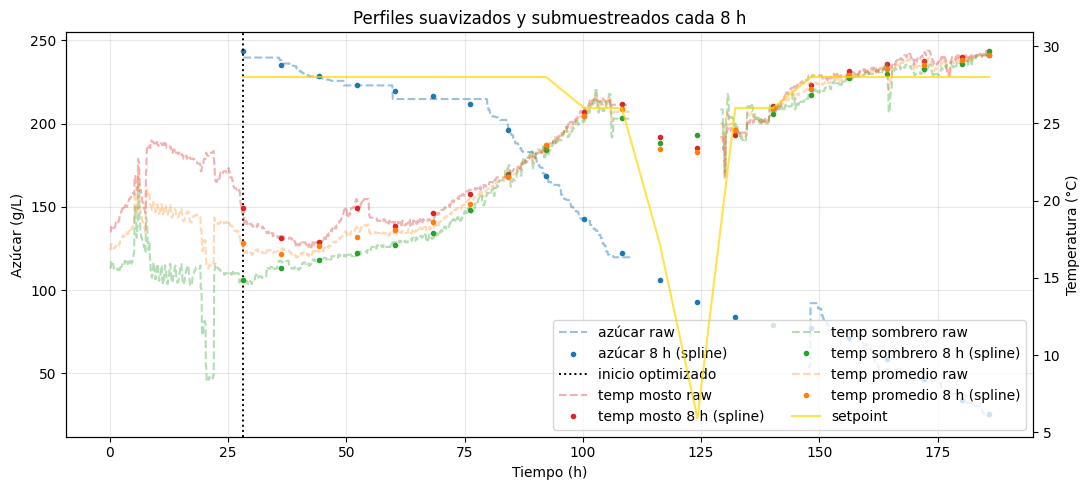

In [33]:
# === Gráfico combinado: datos crudos vs suavizados/submuestreados ===
fig, ax1 = plt.subplots(figsize=(11, 5))
ax2 = ax1.twinx()

ax1.plot(t_hours, azucar_raw, "--", color="tab:blue", alpha=0.45, label="azúcar raw")
ax1.plot(t_opt, azucar_opt, ".", color="tab:blue", ms=6, label=f"azúcar {t_muestreo} h (spline)")

ax2.plot(t_hours, df_sens[col_tm], "--", color="tab:red", alpha=0.35, label="temp mosto raw")
ax2.plot(t_opt, tm_opt, ".", color="tab:red", ms=6, label=f"temp mosto {t_muestreo} h (spline)")

ax2.plot(t_hours, df_sens[col_ts], "--", color="tab:green", alpha=0.35, label="temp sombrero raw")
ax2.plot(t_opt, ts_opt, ".", color="tab:green", ms=6, label=f"temp sombrero {t_muestreo} h (spline)")

ax2.plot(t_hours, df_sens["temp_promedio_raw"], "--", color="tab:orange", alpha=0.30, label="temp promedio raw")
ax2.plot(t_opt, tp_opt, ".", color="tab:orange", ms=6, label=f"temp promedio {t_muestreo} h (spline)")

ax2.plot(t_opt, setpoint_opt, "-", color="gold", alpha=0.7, label="setpoint")

ax1.axvline(t_start_opt, color="k", ls=":", lw=1.4, label="inicio optimizado")

ax1.set_xlabel("Tiempo (h)")
ax1.set_ylabel("Azúcar (g/L)")
ax2.set_ylabel("Temperatura (°C)")
ax1.grid(True, alpha=0.3)

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="lower right", ncol=2)

plt.title(f"Perfiles suavizados y submuestreados cada {t_muestreo} h")
plt.tight_layout()
plt.show()


### Perfiles centrados en t=0 al inicio de fermentación

In [34]:
# azucar_inicial = float(azucar_opt[0])
# print(f"Azúcar inicial (t=0): {azucar_inicial:.2f} g/L")

Azucar_ini = brix_to_sugar(brix_inicial)
print(f'Concentración inicial de azúcar: {Azucar_ini:.2f} (g/L)')

Concentración inicial de azúcar: 239.60 (g/L)


In [35]:
N_ini = Conc_YAN_ini/1000 
print(f'Concentración inicial de N: {N_ini:.4f} (g/L)')  

Concentración inicial de N: 0.1430 (g/L)


In [36]:
X_ini = Biomasa[1]
print(f'Concentración inicial de biomasa: {X_ini:.4f} (g/L)')

Concentración inicial de biomasa: 0.0807 (g/L)


In [37]:
# === Vector con t=0 en inicio de fermentación (primer dato de densidad) ===
t_zero = t_opt - t_opt[0]
perfiles_centrados = {
    "t_horas_cero": t_zero,
    "azucar": azucar_opt,
    "temp_mosto": tm_opt,
    "temp_sombrero": ts_opt,
    "temp_promedio": tp_opt,
    "setpoint": setpoint_opt,
}

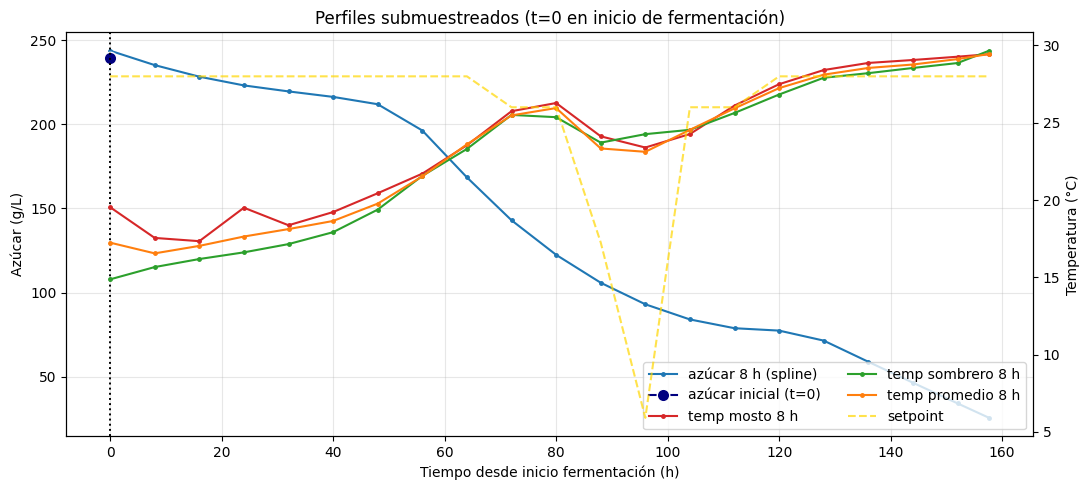

In [38]:
# === Gráfico centrado en t=0 ===
fig, ax1 = plt.subplots(figsize=(11, 5))
ax2 = ax1.twinx()

ax1.plot(t_zero, azucar_opt, ".-", color="tab:blue", ms=5, label=f"azúcar {t_muestreo} h (spline)")
ax1.plot(0, Azucar_ini, marker="o", color="navy", ms=9, mec="white", mfc="navy", label="azúcar inicial (t=0)")

ax2.plot(t_zero, tm_opt, ".-", color="tab:red", ms=5, label=f"temp mosto {t_muestreo} h")
ax2.plot(t_zero, ts_opt, ".-", color="tab:green", ms=5, label=f"temp sombrero {t_muestreo} h")
ax2.plot(t_zero, tp_opt, ".-", color="tab:orange", ms=5, label=f"temp promedio {t_muestreo} h")
ax2.plot(t_zero, setpoint_opt, "--", color="gold", alpha=0.7, label="setpoint")

ax1.axvline(0, color="k", ls=":", lw=1.4)
ax1.set_xlabel("Tiempo desde inicio fermentación (h)")
ax1.set_ylabel("Azúcar (g/L)")
ax2.set_ylabel("Temperatura (°C)")
ax1.grid(True, alpha=0.3)

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="lower right", ncol=2)

plt.title("Perfiles submuestreados (t=0 en inicio de fermentación)")
plt.tight_layout()
plt.show()


### Definición del modelo Zenteno

In [39]:
# -------------------------------- Utilidades numéricas --------------------------------
EPS = 1e-9
BIG = 1e6  # techo de seguridad para estados y tasas


def safe_div(a, b, eps=EPS):
    return a / (b + eps)


def safe_exp(x, lo=-50.0, hi=50.0):
    """exp con saturación del exponente para evitar overflow/underflow extremo."""
    return np.exp(np.clip(x, lo, hi))


def clamp(x, lo, hi):
    return np.minimum(np.maximum(x, lo), hi)


def _real_pos(z):
    """Parte real y clamp a >= 0 (evita ComplexWarning y negativos numéricos)."""
    r = float(np.real(z))
    return r if r > 0.0 else 0.0

In [40]:
# -------------------------------- Modelo dinámico --------------------------------
def zenteno_model(t, x, u, p, apply_nadd_in_model=True):
    """
    Modelo de cinética de fermentación robusto.
    Estados: x = [X, N, G, F, E] (g/L)
    Entradas: u = [T (K), Nadd (g/L/h)]  (Nadd se suma a dN si apply_nadd_in_model=True)
    Parámetros: p[0..13] positivos.
    """
    # Entradas
    T = float(u[0])     # Kelvin
    Nadd = float(u[1])  # g/L/h

    # Estados (no-negatividad y parte real)
    X = _real_pos(x[0])
    N = _real_pos(x[1])
    G = _real_pos(x[2])
    F = _real_pos(x[3])
    E = _real_pos(x[4])

    # Limitar T a un rango físico razonable (0-60 °C)
    T = clamp(T, 273.15, 333.15)

    # Parámetros (positivos)
    vals = [max(float(pi), EPS) for pi in p]
    (mu0, betaG0, betaF0, Kn0, Kg0, Kf0, Kig0, Kie0, Kd0,
     Yxn, Yxg, Yxf, Yeg, Yef) = vals

    # Constantes
    Cde     = 0.0415      # m3/kg E (Salmon 2003)
    Etd     = 130000.0    # kJ/kmol
    R       = 8.314       # kJ/kmol/K (Boulton 1979)
    Eac     = 59453.0     # kJ/kmol (Boulton 1979)
    Eafe    = 11000.0     # kJ/kmol (Zenteno 2010)
    EaKn    = 46055.0     # kJ/kmol (Boulton 1979)
    EaKg    = 46055.0     # kJ/kmol (Boulton 1979)
    EaKf    = 46055.0     # kJ/kmol (Boulton 1979)
    EaKig   = 46055.0     # kJ/kmol (Boulton 1979)
    EaKie   = 46055.0     # kJ/kmol (Boulton 1979)
    Eam     = 37681.0     # kJ/kmol (Boulton 1979)
    m0      = 0.01        # kgS/kg bio/h

    # Arrhenius con exponente acotado
    mu_max    = mu0   * safe_exp(Eac *(T-300.00)/(300.00*R*T))
    betaG_max = betaG0* safe_exp(Eafe*(T-296.15)/(296.15*R*T))
    betaF_max = betaF0* safe_exp(Eafe*(T-296.15)/(296.15*R*T))
    Kn        = Kn0   * safe_exp(EaKn*(T-293.15)/(293.15*R*T))
    Kg        = Kg0   * safe_exp(EaKg*(T-293.15)/(293.15*R*T))
    Kf        = Kf0   * safe_exp(EaKf*(T-293.15)/(293.15*R*T))
    Kig       = Kig0  * safe_exp(EaKig*(T-293.15)/(293.15*R*T))
    Kie       = Kie0  * safe_exp(EaKie*(T-293.15)/(293.15*R*T))
    m         = m0    * safe_exp(Eam *(T-293.30)/(293.30*R*T))

    # Tasas con divisiones seguras
    mu      = mu_max * safe_div(N, N + Kn)
    beta_G  = betaG_max* safe_div(G, G + Kg) * safe_div(Kie, E + Kie)
    beta_F  = betaF_max* safe_div(F, F + Kf) * safe_div(Kig, G + Kig) * safe_div(Kie, E + Kie)

    # Temperatura de muerte térmica con E acotado (evita E**3 enorme)
    E_cap = clamp(E, 0.0, 200.0)
    Td = -0.0001*(E_cap**3) + 0.0049*(E_cap**2) - 0.1279*E_cap + 315.89
    Td = clamp(Td, 273.15, 333.15)

    # Tasa de muerte específica con exponencial segura
    if T >= Td:
        exponent = (Cde*E_cap) + safe_div(Etd*(T-305.65), (305.65*R*T))
        Kd = Kd0 * safe_exp(exponent, lo=-50.0, hi=50.0)
    else:
        Kd = 0.0

    # Mezcla para mantenimiento (evita 0/0)
    GpF = G + F + EPS
    mG = G / GpF
    mF = F / GpF

    # EDOs
    dX = (mu - Kd) * X
    dN = -(mu / max(Yxn, EPS)) * X
    if apply_nadd_in_model:
        dN += Nadd  # Nadd se agrega como tasa en el paso correspondiente
    dG = -((mu / max(Yxg, EPS)) + (beta_G / max(Yeg, EPS)) + m*mG) * X
    dF = -((mu / max(Yxf, EPS)) + (beta_F / max(Yef, EPS)) + m*mF) * X
    dE = (beta_G + beta_F) * X

    dX = float(clamp(dX, -BIG, BIG))
    dN = float(clamp(dN, -BIG, BIG))
    dG = float(clamp(dG, -BIG, BIG))
    dF = float(clamp(dF, -BIG, BIG))
    dE = float(clamp(dE, -BIG, BIG))
    return np.array([dX, dN, dG, dF, dE], dtype=float)

In [41]:
def zenteno_jacobian(t, x, u, p, apply_nadd_in_model=True):
    """
    Jacobiano analítico df/dx de zenteno_model respecto de x=[X,N,G,F,E].
    Retorna matriz (5,5).
    """
    # Estados (real + >=0)
    X = _real_pos(x[0]); N = _real_pos(x[1]); G = _real_pos(x[2]); F = _real_pos(x[3]); E = _real_pos(x[4])

    # Entrada
    T = float(u[0])
    T = clamp(T, 273.15, 333.15)

    # Parámetros (positivos)
    vals = [max(float(pi), EPS) for pi in p]
    (mu0, betaG0, betaF0, Kn0, Kg0, Kf0, Kig0, Kie0, Kd0,
     Yxn, Yxg, Yxf, Yeg, Yef) = vals

    # Constantes (mismas que en zenteno_model)
    Cde     = 0.0415
    Etd     = 130000.0
    R       = 8.314
    Eac     = 59453.0
    Eafe    = 11000.0
    EaKn    = 46055.0
    EaKg    = 46055.0
    EaKf    = 46055.0
    EaKig   = 46055.0
    EaKie   = 46055.0
    Eam     = 37681.0
    m0      = 0.01

    # Arrhenius (dependen de T, no de estados)
    mu_max    = mu0   * safe_exp(Eac *(T-300.00)/(300.00*R*T))
    betaG_max = betaG0* safe_exp(Eafe*(T-296.15)/(296.15*R*T))
    betaF_max = betaF0* safe_exp(Eafe*(T-296.15)/(296.15*R*T))
    Kn        = Kn0   * safe_exp(EaKn*(T-293.15)/(293.15*R*T))
    Kg        = Kg0   * safe_exp(EaKg*(T-293.15)/(293.15*R*T))
    Kf        = Kf0   * safe_exp(EaKf*(T-293.15)/(293.15*R*T))
    Kig       = Kig0  * safe_exp(EaKig*(T-293.15)/(293.15*R*T))
    Kie       = Kie0  * safe_exp(EaKie*(T-293.15)/(293.15*R*T))
    m         = m0    * safe_exp(Eam *(T-293.30)/(293.30*R*T))

    # -------- Tasas y derivadas parciales --------
    # mu = mu_max * N/(N+Kn)
    denomN = (N + Kn)
    mu     = mu_max * safe_div(N, denomN)
    dmu_dN = mu_max * (Kn / (denomN**2))

    # beta_G = betaG_max * G/(G+Kg) * Kie/(E+Kie)
    denomG = (G + Kg)
    denomE = (E + Kie)
    beta_G = betaG_max * safe_div(G, denomG) * safe_div(Kie, denomE)

    # d/dG: d (G/(G+Kg)) = Kg/(G+Kg)^2
    dbG_dG = betaG_max * (Kg / (denomG**2)) * safe_div(Kie, denomE)

    # d/dE: d (Kie/(E+Kie)) = -Kie/(E+Kie)^2
    dbG_dE = betaG_max * safe_div(G, denomG) * (-Kie / (denomE**2))

    # beta_F = betaF_max * F/(F+Kf) * Kig/(G+Kig) * Kie/(E+Kie)
    denomF  = (F + Kf)
    denomGK = (G + Kig)
    beta_F  = betaF_max * safe_div(F, denomF) * safe_div(Kig, denomGK) * safe_div(Kie, denomE)

    # d/dF: d(F/(F+Kf)) = Kf/(F+Kf)^2
    dbF_dF = betaF_max * (Kf / (denomF**2)) * safe_div(Kig, denomGK) * safe_div(Kie, denomE)

    # d/dG: d(Kig/(G+Kig)) = -Kig/(G+Kig)^2
    dbF_dG = betaF_max * safe_div(F, denomF) * (-Kig / (denomGK**2)) * safe_div(Kie, denomE)

    # d/dE: mismo factor inhibición etanol
    dbF_dE = betaF_max * safe_div(F, denomF) * safe_div(Kig, denomGK) * (-Kie / (denomE**2))

    # -------- Kd(E,T) y derivada dKd/dE --------
    E_cap = clamp(E, 0.0, 200.0)
    Td = -0.0001*(E_cap**3) + 0.0049*(E_cap**2) - 0.1279*E_cap + 315.89
    Td = clamp(Td, 273.15, 333.15)

    if T >= Td:
        exponent = (Cde*E_cap) + safe_div(Etd*(T-305.65), (305.65*R*T))
        Kd = Kd0 * safe_exp(exponent, lo=-50.0, hi=50.0)
        # derivada respecto a E: d/dE exp(Cde*E) = Cde*exp(...)
        # (aquí ignoramos derivada de clamp si E>200; dentro del rango es exacta)
        dKd_dE = Cde * Kd if (0.0 < E < 200.0) else 0.0
    else:
        Kd = 0.0
        dKd_dE = 0.0

    # -------- fracciones mantenimiento phi_G, phi_F --------
    sumGF = G + F + EPS
    phi_G = G / sumGF
    phi_F = F / sumGF

    # derivadas:
    # phi_G = G/(G+F) -> dphiG/dG = F/(G+F)^2, dphiG/dF = -G/(G+F)^2
    dphiG_dG =  F / (sumGF**2)
    dphiG_dF = -G / (sumGF**2)

    # phi_F = F/(G+F) -> dphiF/dF = G/(G+F)^2, dphiF/dG = -F/(G+F)^2
    dphiF_dF =  G / (sumGF**2)
    dphiF_dG = -F / (sumGF**2)

    # -------- Construcción Jacobiano J = df/dx --------
    J = np.zeros((5, 5), dtype=float)

    # f0 = dX = (mu - Kd)*X
    J[0, 0] = (mu - Kd)
    J[0, 1] = dmu_dN * X
    J[0, 4] = -(dKd_dE) * X

    # f1 = dN = -(mu/Yxn)*X (+ Nadd no afecta df/dx)
    J[1, 0] = -(mu / Yxn)
    J[1, 1] = -(dmu_dN / Yxn) * X

    # f2 = dG = -[(mu/Yxg) + (beta_G/Yeg) + m*phi_G]*X
    term_G = (mu / Yxg) + (beta_G / Yeg) + m*phi_G
    J[2, 0] = -term_G
    J[2, 1] = -((dmu_dN / Yxg) * X)
    J[2, 2] = -(((dbG_dG / Yeg) + m*dphiG_dG) * X)
    J[2, 3] = -((m*dphiG_dF) * X)
    J[2, 4] = -(((dbG_dE / Yeg) * X))

    # f3 = dF = -[(mu/Yxf) + (beta_F/Yef) + m*phi_F]*X
    term_F = (mu / Yxf) + (beta_F / Yef) + m*phi_F
    J[3, 0] = -term_F
    J[3, 1] = -((dmu_dN / Yxf) * X)
    J[3, 2] = -(((dbF_dG / Yef) + m*dphiF_dG) * X)
    J[3, 3] = -(((dbF_dF / Yef) + m*dphiF_dF) * X)
    J[3, 4] = -(((dbF_dE / Yef) * X))

    # f4 = dE = (beta_G + beta_F)*X
    J[4, 0] = (beta_G + beta_F)
    J[4, 2] = (dbG_dG + dbF_dG) * X
    J[4, 3] = (dbF_dF) * X
    J[4, 4] = (dbG_dE + dbF_dE) * X

    return J


### Optimización de parámetros

In [42]:
## --- Imports + helpers + u(t) (T interpolada, Nadd=0) --- ##

def _as_float_1d(a):
    return np.asarray(a, dtype=float).reshape(-1)

def make_u_fun_from_arrays(t_hours, T_celsius, nadd_rate=None):
    t_hours = _as_float_1d(t_hours)
    T_celsius = _as_float_1d(T_celsius)

    if t_hours.size != T_celsius.size:
        raise ValueError("t_hours y T_celsius deben tener el mismo largo.")
    if np.any(np.diff(t_hours) <= 0):
        raise ValueError("t_hours debe ser estrictamente creciente.")

    if nadd_rate is None:
        nadd_rate = np.zeros_like(t_hours, dtype=float)
    else:
        nadd_rate = _as_float_1d(nadd_rate)
        if nadd_rate.size != t_hours.size:
            raise ValueError("nadd_rate debe tener el mismo largo que t_hours.")

    def u_fun(t):
        Tc = np.interp(t, t_hours, T_celsius)
        Tk = Tc + 273.15
        nadd = np.interp(t, t_hours, nadd_rate)  # aquí 0
        return np.array([Tk, nadd], dtype=float)

    return u_fun

In [43]:
## --- x0 desde azúcar total (G y F 50/50) + simulador --- ##

def build_x0(X0, N0, S0_total, E0=0.0, fG0=0.5):
    fG0 = float(np.clip(fG0, 0.0, 1.0))
    G0 = fG0 * S0_total
    F0 = (1.0 - fG0) * S0_total
    return np.array([X0, N0, G0, F0, E0], dtype=float)

J_SPARSE = np.array([
    [1, 1, 0, 0, 1],
    [1, 1, 0, 0, 0],
    [1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1],
    [1, 0, 1, 1, 1],
], dtype=bool)

def simulate_zenteno(p, t_eval, x0, u_fun, method="Radau",
                     atol=1e-8, rtol=1e-6, apply_nadd_in_model=True,
                     use_jac=True, use_sparsity=False):

    t_eval = _as_float_1d(t_eval)
    t0, tf = float(t_eval[0]), float(t_eval[-1])

    def f(t, x):
        u = u_fun(t)
        return zenteno_model(t, x, u, p, apply_nadd_in_model=apply_nadd_in_model)

    if use_jac:
        def j(t, x):
            u = u_fun(t)
            return zenteno_jacobian(t, x, u, p, apply_nadd_in_model=apply_nadd_in_model)
    else:
        j = None

    sol = solve_ivp(
        fun=f,
        t_span=(t0, tf),
        y0=np.asarray(x0, dtype=float),
        method=method,
        t_eval=t_eval,
        jac=j if use_jac else None,                         # <-- AQUÍ
        jac_sparsity=J_SPARSE if use_sparsity else None,    # opcional
        atol=atol,
        rtol=rtol,
        vectorized=False
    )

    if not sol.success:
        sol2 = solve_ivp(
            fun=f,
            t_span=(t0, tf),
            y0=np.asarray(x0, dtype=float),
            method=method,
            t_eval=t_eval,
            jac=j if use_jac else None,
            jac_sparsity=J_SPARSE if use_sparsity else None,
            atol=max(atol*10, 1e-6),
            rtol=max(rtol*10, 1e-4),
            vectorized=False
        )
        if not sol2.success:
            raise RuntimeError(f"solve_ivp falló: {sol.message} / retry: {sol2.message}")
        sol = sol2

    return sol.t, sol.y.T



def predict_S_total(Xsim):
    G = Xsim[:, 2]
    F = Xsim[:, 3]
    return G + F

In [ ]:
## --- Armar tu dataframe de datos (azúcar) y escalas (normalización) -- ##

# Vectores base
t_zero = _as_float_1d(t_zero)
# tp_opt = _as_float_1d(tp_opt)
tp_opt = _as_float_1d(tp_opt)
azucar_opt = _as_float_1d(azucar_opt)

if not (t_zero.size == tp_opt.size == azucar_opt.size):
    raise ValueError("t_zero, tp_opt y azucar_opt deben tener el mismo largo (como lo estás usando ahora).")

# DataFrame de medición (solo azúcar total)
df_data = pd.DataFrame({
    "t_h": t_zero,
    "S": azucar_opt
}).sort_values("t_h").reset_index(drop=True)

# --- Escalas de normalización (NO pesos arbitrarios) ---
# Azúcar: usa el azúcar inicial como referencia (recomendado)
S_ref = float(Azucar_ini)  # g/L
S_ref = max(S_ref, 1.0)    # evita dividir por cero o números muy chicos

# Etanol: referencia = etanol final observado
E_final_obs = float(alcohol_final_obs)  # g/L
E_ref = max(abs(E_final_obs), 1.0)

# Factor opcional para darle más importancia al etanol (1 = balanceado)
alpha_E = 10.0  # prueba 1, 2, 5, 10 si quieres forzar E_final

# Guardamos en un dict por claridad
scales = {"S": S_ref, "E": E_ref, "alpha_E": alpha_E}

scales

{'S': 239.59986415999998, 'E': 92.34809999999999, 'alpha_E': 20.0}

In [46]:
## --- u(t) y x0 para simulación --- ##
# u(t): T(t) + Nadd(t)=0
u_fun = make_u_fun_from_arrays(t_zero, tm_opt, nadd_rate=None)

# x0 desde iniciales (azúcar total repartida 50/50)
x0 = build_x0(X_ini, N_ini, Azucar_ini, E0=0.0, fG0=0.5)


## -- Definir p0, bounds, residuals y correr calibración (solo S) --- ##

PARAM_NAMES = [
    "mu0", "betaG0", "betaF0", "Kn0", "Kg0", "Kf0", "Kig0", "Kie0", "Kd0",
    "Yxn", "Yxg", "Yxf", "Yeg", "Yef"
]
NAME_TO_IDX = {n:i for i,n in enumerate(PARAM_NAMES)}

KD0_FIXED_VALUE = 0.0001  # <- regla dura

# Este será tu "default" (puede ser cualquiera, se sobreescribe por estructura)
p_base_default = np.array([
    0.2,   # mu0
    0.3,   # betaG0
    0.25,  # betaF0
    0.08,  # Kn0
    10.0,  # Kg0
    10.0,  # Kf0
    10.0,  # Kig0
    10.0,  # Kie0
    KD0_FIXED_VALUE,  # Kd0 fijo
    20.0,  # Yxn
    1.00,  # Yxg
    1.00,  # Yxf
    0.50,  # Yeg
    0.50   # Yef
], dtype=float)

# bounds por nombre (ajústalos si te dieron otros)
DEFAULT_BOUNDS = {
    "mu0":    (1e-4, 10.0),
    "betaG0": (1e-4, 10.0),
    "betaF0": (1e-4, 10.0),
    "Kn0":    (1e-6, 10.0),
    "Kg0":    (1e-3, 500.0),
    "Kf0":    (1e-3, 500.0),
    "Kig0":   (1e-3, 500.0),
    "Kie0":   (1e-3, 500.0),
    "Kd0":    (KD0_FIXED_VALUE, KD0_FIXED_VALUE),
    "Yxn":    (1e-3, 200.0),
    "Yxg":    (1e-3, 200.0),
    "Yxf":    (1e-3, 200.0),
    "Yeg":    (1e-4, 10.0),
    "Yef":    (1e-4, 10.0),
}

def bounds_for_free(free_names, bounds_dict=DEFAULT_BOUNDS):
    lb, ub = [], []
    for n in free_names:
        a, b = bounds_dict[n]
        lb.append(a); ub.append(b)
    return np.array(lb, float), np.array(ub, float)

def prepare_from_structure(structure, p_base_default):
    """
    structure = {"fixed": {...}, "free": {...}}
    - structure["fixed"] trae valores para parámetros fijados
    - structure["free"] trae valores iniciales para parámetros libres
    Retorna: theta0, (lb,ub), theta_to_p, free_names
    """
    fixed_params = dict(structure.get("fixed", {}))
    free_init = dict(structure.get("free", {}))

    # regla dura: Kd0 siempre fijo
    fixed_params["Kd0"] = KD0_FIXED_VALUE
    free_init.pop("Kd0", None)

    free_names = list(free_init.keys())

    # arma p_base usado (para consistencia)
    p_base = np.array(p_base_default, float).copy()
    p_base[NAME_TO_IDX["Kd0"]] = KD0_FIXED_VALUE

    for n,v in fixed_params.items():
        p_base[NAME_TO_IDX[n]] = float(v)
    for n,v in free_init.items():
        p_base[NAME_TO_IDX[n]] = float(v)

    idx_free = [NAME_TO_IDX[n] for n in free_names]

    def theta_to_p(theta):
        p = np.array(p_base, float).copy()
        # aplica fijos sí o sí
        for n,v in fixed_params.items():
            p[NAME_TO_IDX[n]] = float(v)
        # aplica libres
        theta = np.asarray(theta, float).reshape(-1)
        if theta.size != len(idx_free):
            raise ValueError("theta tiene largo incorrecto")
        p[idx_free] = theta
        # vuelve a forzar kd0
        p[NAME_TO_IDX["Kd0"]] = KD0_FIXED_VALUE
        return p

    theta0 = np.array([free_init[n] for n in free_names], dtype=float)
    lb_theta, ub_theta = bounds_for_free(free_names)

    return theta0, (lb_theta, ub_theta), theta_to_p, free_names


In [47]:
# ------------------ Tus estructuras (convertidas) ------------------

MODEL_1 = {
    "fixed": {},  # ninguno fijo (excepto Kd0 que se fuerza)
    "free": {
        "mu0": 0.278601,
        "betaG0": 1.478706,
        "betaF0": 1.792848,
        "Kn0": 0.064151,
        "Kg0": 58.122659,
        "Kf0": 59.222824,
        "Kig0": 71.630423,
        "Kie0": 90.865909,
        "Yxn": 13.617817,
        "Yxg": 1.804689,
        "Yxf": 6.470613,
        "Yeg": 0.735207,
        "Yef": 0.754100,
    }
}

MODEL_1750 = {
    "fixed": {
        "mu0": 0.197200,
        "betaG0": 0.229613,
        "betaF0": 0.248792,
        "Kf0": 7.165650,
        "Kie0": 42.528284,
        "Yeg": 0.451746,
    },
    "free": {
        "Kn0": 0.017264,
        "Kg0": 26.204288,
        "Kig0": 134.167400,
        "Yxn": 35.363591,
        "Yxg": 15.347849,
        "Yxf": 7.769926,
        "Yef": 0.836931,
    }
}

MODEL_1860 = {
    "fixed": {
        "mu0": 0.197200,
        "betaG0": 0.229613,
        "betaF0": 0.248792,
        "Kig0": 44.150670,
        "Kie0": 42.528284,
        "Yxg": 1.393119,
    },
    "free": {
        "Kn0": 0.027142,
        "Kg0": 53.008633,
        "Kf0": 60.118211,
        "Yxn": 69.985750,
        "Yxf": 7.390758,
        "Yeg": 0.995332,
        "Yef": 0.927205,
    }
}

MODEL_2264 = {
    "fixed": {
        "Kn0": 0.009647,
        "Kg0": 8.551854,
        "Kf0": 7.165650,
        "Kig0": 44.150670,
        "Kie0": 42.528284,
        "Yxf": 1.642634,
    },
    "free": {
        "mu0": 0.277041,
        "betaG0": 0.428944,
        "betaF0": 0.516588,
        "Yxn": 28.923223,
        "Yxg": 3.330956,
        "Yeg": 0.780173,
        "Yef": 0.879215,
    }
}

MODELS = {
    "1": MODEL_1,
    "1750": MODEL_1750,
    "1860": MODEL_1860,
    "2264": MODEL_2264
}


# ------------------ Selección de modelo ------------------
MODEL_ID = "1"   # <--- CAMBIA AQUÍ: "1", "1750", "1860", "2264"
structure = MODELS[MODEL_ID]

theta0, (lb_theta, ub_theta), theta_to_p, free_names = prepare_from_structure(structure, p_base_default)

print("Modelo:", MODEL_ID)
print("Libres:", free_names)
print("theta0:", theta0)

Modelo: 1
Libres: ['mu0', 'betaG0', 'betaF0', 'Kn0', 'Kg0', 'Kf0', 'Kig0', 'Kie0', 'Yxn', 'Yxg', 'Yxf', 'Yeg', 'Yef']
theta0: [2.7860100e-01 1.4787060e+00 1.7928480e+00 6.4151000e-02 5.8122659e+01
 5.9222824e+01 7.1630423e+01 9.0865909e+01 1.3617817e+01 1.8046890e+00
 6.4706130e+00 7.3520700e-01 7.5410000e-01]


In [48]:
# ------------------ Residuales y loss (normalizados) ------------------
t_eval_meas = df_data["t_h"].to_numpy(dtype=float)
S_obs = df_data["S"].to_numpy(dtype=float)

# Si tu etanol final es al final del tramo de azúcar, esto está perfecto:
t_E_final = float(t_eval_meas[-1])
# Si NO coincide, puedes setearlo manual:
# t_E_final = float(t_alcohol_final)

def residuals_theta(theta):
    p = theta_to_p(theta)

    # Asegura que simulamos incluyendo el punto del etanol final
    if t_E_final <= t_eval_meas[-1] + 1e-12:
        t_eval = t_eval_meas
    else:
        t_eval = np.r_[t_eval_meas, t_E_final]

    _, Xsim = simulate_zenteno(
        p, t_eval=t_eval, x0=x0, u_fun=u_fun,
        method="Radau", atol=1e-8, rtol=1e-6, apply_nadd_in_model=True, 
        use_sparsity=True)

    # --- Azúcar: residual normalizado ---
    S_hat = predict_S_total(Xsim[:len(t_eval_meas), :])
    rS = (S_hat - S_obs) / scales["S"]

    # --- Etanol final: residual normalizado (1 punto) ---
    E_hat_final = float(Xsim[-1, 4])
    rE = scales["alpha_E"] * (E_hat_final - E_final_obs) / scales["E"]

    return np.r_[rS, rE]

def loss_rmse(theta):
    r = residuals_theta(theta)
    return float(np.sqrt(np.mean(r**2)))

In [49]:
# Revisar zenteno_jacobian

def check_jacobian_once(p, x_test, t_test, u_fun, eps=1e-6):
    u = u_fun(t_test)
    J_ana = zenteno_jacobian(t_test, x_test, u, p)

    f0 = zenteno_model(t_test, x_test, u, p)
    J_num = np.zeros_like(J_ana)

    for j in range(len(x_test)):
        x2 = np.array(x_test, float)
        x2[j] += eps
        f2 = zenteno_model(t_test, x2, u, p)
        J_num[:, j] = (f2 - f0) / eps

    err = np.linalg.norm(J_ana - J_num) / max(np.linalg.norm(J_num), 1e-12)
    return err

# ejemplo de chequeo
x_test = x0.copy()
t_test = float(t_zero[len(t_zero)//2])
err_rel = check_jacobian_once(p_base_default, x_test, t_test, u_fun)
print("Error relativo Jacobiano (ideal ~1e-3 o menos):", err_rel)


Error relativo Jacobiano (ideal ~1e-3 o menos): 2.3132557178003608e-07


In [50]:
# ------------------ Optimización (elige una) ------------------

USE_GLOBAL = True  # <--- pon False si quieres solo local

if USE_GLOBAL:
    bounds_de = list(zip(lb_theta, ub_theta))
    res_de = differential_evolution(
        func=loss_rmse,
        bounds=bounds_de,
        maxiter=24,
        popsize=6,
        polish=False,
        seed=1,
        updating="deferred",
        workers=1
    )
    theta_seed = res_de.x
    print("RMSE scaled (global):", res_de.fun)
else:
    theta_seed = theta0

out = least_squares(
    fun=residuals_theta,
    x0=theta_seed,
    bounds=(lb_theta, ub_theta),
    method="trf",
    loss="soft_l1",
    f_scale=1.0,
    max_nfev=500,
    verbose=2
)

theta_hat = out.x
p_hat = theta_to_p(theta_hat)

print("Kd0 final (debe ser 0.0001):", p_hat[NAME_TO_IDX["Kd0"]])
display(pd.Series(p_hat, index=PARAM_NAMES))

RMSE scaled (global): 0.06160835973403092
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         4.1653e-02                                    1.26e+01    
       1              6         3.9744e-02      1.91e-03       4.33e-03       4.71e+01    
       2              7         3.9602e-02      1.42e-04       4.18e-03       6.66e+01    
       3             12         3.9602e-02      0.00e+00       0.00e+00       6.66e+01    
`xtol` termination condition is satisfied.
Function evaluations 12, initial cost 4.1653e-02, final cost 3.9602e-02, first-order optimality 6.66e+01.
Kd0 final (debe ser 0.0001): 0.0001


mu0         2.925185
betaG0      2.342910
betaF0      5.824143
Kn0         6.524928
Kg0       316.350405
Kf0       463.296961
Kig0      334.239491
Kie0       91.257581
Kd0         0.000100
Yxn       123.908288
Yxg        72.037122
Yxf       112.683858
Yeg         0.670566
Yef         0.199582
dtype: float64

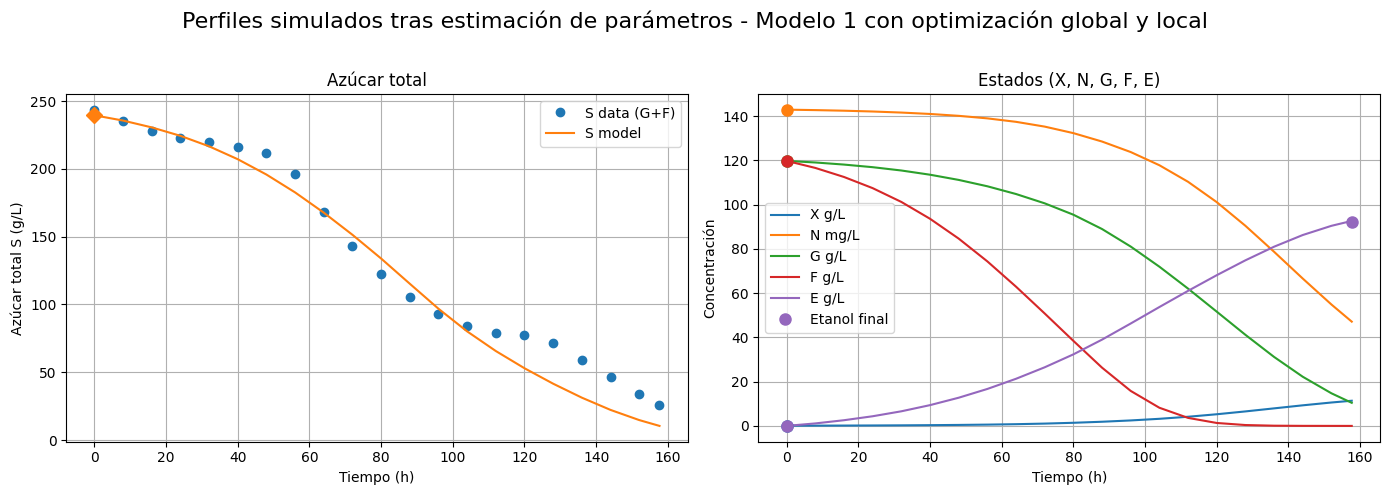

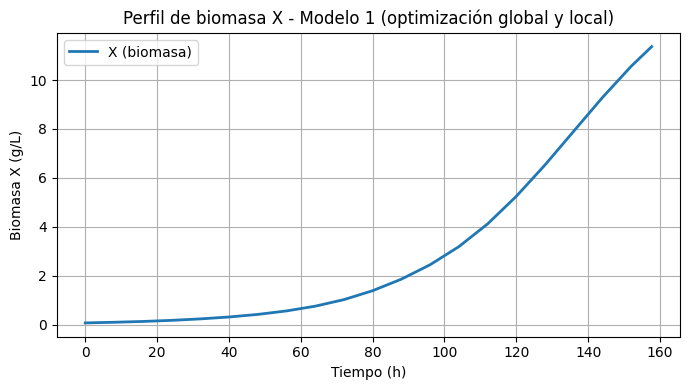

In [52]:
## --- Graficar ajuste final (S y, si quieres, estados completos) --- ##

# Simulación final
t_sim, Xsim = simulate_zenteno(p_hat, t_eval=t_zero, x0=x0, u_fun=u_fun, method="Radau")
S_hat = predict_S_total(Xsim)

# Figura con subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
if USE_GLOBAL:
    fig.suptitle(f'Perfiles simulados tras estimación de parámetros - Modelo {MODEL_ID} con optimización global y local', fontsize=16)
else: 
    fig.suptitle(f'Perfiles simulados tras estimación de parámetros - Modelo {MODEL_ID} con optimización local', fontsize=16)

# Gráfico 1: Azúcar total
ln_s_data = ax1.plot(t_zero, azucar_opt, "o", label="S data (G+F)")
ln_s_model = ax1.plot(t_sim, S_hat, "-", label="S model")
ax1.set_title("Azúcar total")
s_color = ln_s_model[0].get_color()
# punto inicial de S (condición inicial)
if 'Azucar_ini' in globals():
    t0_s = float(t_zero[0]) if len(t_zero) > 0 else (float(t_sim[0]) if len(t_sim) > 0 else 0.0)
    ax1.plot(t0_s, float(Azucar_ini), marker='D', color=s_color, ms=8)

ax1.set_xlabel("Tiempo (h)")
ax1.set_ylabel("Azúcar total S (g/L)")
ax1.legend()
ax1.grid()

# Gráfico 2: Estados
labels = ["X", "N", "G", "F", "E"]
colors = {}
for i, lab in enumerate(labels):
    if lab == "N":
        ln = ax2.plot(t_sim, Xsim[:, i]*1000, label=f"{lab} mg/L")
    else:
        ln = ax2.plot(t_sim, Xsim[:, i], label=f"{lab} g/L")
    colors[lab] = ln[0].get_color()
    

ax2.set_title("Estados (X, N, G, F, E)")
# punto(s) inicial(es) de estados (usando x0)
if 'x0' in globals() and x0 is not None:
    t0_state = float(t_sim[0]) if len(t_sim) > 0 else (float(t_zero[0]) if len(t_zero) > 0 else 0.0)
    for i, lab in enumerate(labels):
        init_val = float(x0[i]) * 1000.0 if i == 1 else float(x0[i])
        ax2.plot(t0_state, init_val, marker='o', color=colors.get(lab, None), ms=8)

ax2.set_xlabel("Tiempo (h)")
ax2.set_ylabel("Concentración")
ax2.legend()
ax2.grid()

# Añadir punto 'alcohol_final_obs' con el color de etanol (si la variable existe)
alcohol = globals().get("alcohol_final_obs")
if alcohol is not None:
    t_alc = globals().get("t_alcohol_final", float(t_sim[-1]) if len(t_sim) > 0 else float(t_zero[-1]))
    color_to_use = colors.get('E', None) or 'red'
    ax2.plot(t_alc, float(alcohol), "o", color=color_to_use, ms=8, label="Etanol final")
    ax2.legend()

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

plt.figure(figsize=(7, 4))

if USE_GLOBAL:
    plt.title(f"Perfil de biomasa X - Modelo {MODEL_ID} (optimización global y local)", fontsize=12)
else:
    plt.title(f"Perfil de biomasa X - Modelo {MODEL_ID} (optimización local)", fontsize=12)


plt.plot(t_sim, Xsim[:, 0], "-", color="tab:blue", lw=2, label="X (biomasa)")
plt.xlabel("Tiempo (h)")
plt.ylabel("Biomasa X (g/L)")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()